# Stitching with compute backends

multiview-stitcher supports pluggable compute backends. The default backend
is **NumPy/SciPy** (CPU), but you can switch to a different backend such as **CuPy** (GPU) for
significant speedups on CUDA-capable hardware.

In this notebook, we present the basic usage of the backend functionality.
Additionally, we compare the performance and verify the correctness of different backends.

The backend feature currently supports these four functions:

| Function | Module | What it does |
|---|---|---|
| `transform_data()` | `transformation` | Affine transform on raw arrays |
| `get_blending_weights()` | `weights` | Cosine blending weights for fusion |
| `register()` | `registration` | Pairwise tile registration |
| `fuse()` | `fusion` | Full mosaic fusion pipeline |

**Requirements:** `multiview-stitcher`, `cupy` (e.g. `pip install cupy-cuda12x`),
optionally `cucim` for GPU-native phase cross-correlation.

Hardware x Backend Matrix

<table style="width: 100%; table-layout: fixed; border-collapse: collapse;">
  <thead>
    <tr>
      <th style="width: 16.66%; text-align: center;"></th>
      <th style="width: 16.66%; text-align: center;">array-api (numpy, cupy, dpnp)</th>
      <th style="width: 16.66%; text-align: center;">numpy-legacy</th>
      <th style="width: 16.66%; text-align: center;">cupy-legacy</th>
      <th style="width: 16.66%; text-align: center;">numba</th>
      <th style="width: 16.66%; text-align: center;">jax</th>
      <th style="width: 16.66%; text-align: center;">MLX</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align: center;"><strong>CPU</strong></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;"><strong>Nvidia GPU</strong></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;"><strong>AMD GPU</strong></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;"><strong>Intel GPU</strong></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;"><strong>Google TPU</strong></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
      <td style="text-align: center;"></td>
    </tr>
    <tr>
      <td style="text-align: center;"><strong>Apple M-series</strong></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;"></td>
      <td style="text-align: center;">x</td>
    </tr>
  </tbody>
</table>

* also exists as cupy+numba combination

## 1. Setup

In [1]:
import time
import platform
import numpy as np
import dask

import multiview_stitcher
from multiview_stitcher import (
    fusion, msi_utils, registration, sample_data, transformation, weights,
)
from multiview_stitcher import spatial_image_utils as si_utils
from multiview_stitcher import param_utils
from multiview_stitcher.backends import get_backend, _REGISTRY
from multiview_stitcher.io import METADATA_TRANSFORM_KEY

print(f"multiview-stitcher version: {multiview_stitcher.__version__}")
print(f"Registered backends: {list(_REGISTRY.keys())}\n")

# --- CPU info (shared by all CPU backends) ---
cpu_name = platform.processor() or platform.machine()
try:
    with open("/proc/cpuinfo") as f:
        for line in f:
            if line.startswith("model name"):
                cpu_name = line.split(":", 1)[1].strip()
                break
except FileNotFoundError:
    pass

# --- Check each backend: package version and device info ---
for name in _REGISTRY:
    print(f"Backend: {name!r}")

    if name in ("numpy", "numpy-legacy"):
        print(f"  Package: numpy {np.__version__}")
        print(f"  Device:  {cpu_name}")

    elif name in ("cupy", "cupy-legacy"):
        try:
            import cupy as cp
            print(f"  Package: cupy {cp.__version__}")
            runtime = "ROCm (HIP)" if cp.cuda.runtime.is_hip else "CUDA"
            print(f"  Runtime: {runtime}")
            for dev_id in range(cp.cuda.runtime.getDeviceCount()):
                props = cp.cuda.runtime.getDeviceProperties(dev_id)
                mem = cp.cuda.Device(dev_id).mem_info
                print(f"  Device {dev_id}: {props['name'].decode()}, "
                      f"{mem[1] / 1e9:.1f} GB total, {mem[0] / 1e9:.1f} GB free")
        except Exception as e:
            print(f"  Not available: {e}")

    elif name == "dpnp":
        try:
            import dpnp
            print(f"  Package: dpnp {dpnp.__version__}")
            import dpctl
            for dev in dpctl.get_devices():
                print(f"  Device:  {dev.name} ({dev.backend.name})")
        except Exception as e:
            print(f"  Not available: {e}")

    elif name == "numba":
        try:
            import numba
            print(f"  Package: numba {numba.__version__}")
            print(f"  Device:  {cpu_name}")
            print(f"  Threads: {numba.config.NUMBA_NUM_THREADS}")
        except Exception as e:
            print(f"  Not available: {e}")

    elif name == "jax":
        try:
            import jax
            print(f"  Package: jax {jax.__version__}")
            for dev in jax.devices():
                if dev.platform == "cpu":
                    print(f"  Device:  {cpu_name} (jax cpu)")
                else:
                    print(f"  Device:  {dev.device_kind} (jax {dev.platform})")
        except Exception as e:
            print(f"  Not available: {e}")

    elif name == "mlx":
        try:
            import mlx.core as mx
            print(f"  Package: mlx {mx.__version__}")
            print(f"  Device:  Apple Silicon (unified memory)")
        except Exception as e:
            print(f"  Not available: {e}")

    else:
        print(f"  (no device info available)")

    print()

multiview-stitcher version: 0.1.49.dev0+g3d69a6c71.d20260326
Registered backends: ['numpy', 'numpy-legacy', 'cupy', 'cupy-legacy', 'jax']

Backend: 'numpy'
  Package: numpy 2.0.2
  Device:  Intel(R) Xeon(R) Gold 6130 CPU @ 2.10GHz

Backend: 'numpy-legacy'
  Package: numpy 2.0.2
  Device:  Intel(R) Xeon(R) Gold 6130 CPU @ 2.10GHz

Backend: 'cupy'
  Package: cupy 13.4.0
  Runtime: CUDA
  Device 0: NVIDIA GeForce RTX 2080 Ti, 11.3 GB total, 11.2 GB free

Backend: 'cupy-legacy'
  Package: cupy 13.4.0
  Runtime: CUDA
  Device 0: NVIDIA GeForce RTX 2080 Ti, 11.3 GB total, 11.2 GB free

Backend: 'jax'
  Package: jax 0.9.2
  Device:  NVIDIA GeForce RTX 2080 Ti (jax gpu)



## 2. Quick demo: using the backend parameter

Every backend-aware function accepts `backend="numpy"` (default) or
`backend="cupy"`. The API is otherwise identical.

In [2]:
# Generate a small 2D dataset for the demo
demo_sims = sample_data.generate_tiled_dataset(
    ndim=2, N_c=1, N_t=1, tile_size=50,
    tiles_x=2, tiles_y=2, tiles_z=1,
    overlap=10, spacing_x=1, spacing_y=1, spacing_z=1,
)
demo_sdims = si_utils.get_spatial_dims_from_sim(demo_sims[0])
print(f"Demo tiles: {len(demo_sims)}, shape: {demo_sims[0].shape}")

# --- transform_data ---
sim = demo_sims[0].sel(t=demo_sims[0].coords["t"][0],
                        c=demo_sims[0].coords["c"][0]).astype(np.float32)
output_props = {
    "spacing": {d: 1.0 for d in demo_sdims},
    "origin":  {d: 0.0 for d in demo_sdims},
    "shape":   {d: 50  for d in demo_sdims},
}
result = transformation.transform_data(
    np.asarray(sim.data),
    p=param_utils.identity_transform(len(demo_sdims)),
    input_spacing=si_utils.get_spacing_from_sim(sim, asarray=True),
    input_origin=si_utils.get_origin_from_sim(sim, asarray=True),
    output_stack_properties=output_props,
    spatial_dims=demo_sdims,
    backend="numpy",  # or "cupy"
)
print(f"transform_data  -> {type(result).__name__}, shape {result.shape}")

# --- get_blending_weights ---
source_bb = {
    "spacing": {d: 1.0 for d in demo_sdims},
    "origin":  {d: 0.0 for d in demo_sdims},
    "shape":   {d: 50  for d in demo_sdims},
}
w = weights.get_blending_weights(
    target_bb=output_props, source_bb=source_bb,
    affine=np.eye(len(demo_sdims) + 1),
    backend="numpy",  # or "cupy"
)
print(f"blending_weights -> {type(w).__name__}, shape {w.shape}")

# --- register ---
demo_msims = [msi_utils.get_msim_from_sim(s, scale_factors=[]) for s in demo_sims]
params = registration.register(
    demo_msims,
    reg_channel_index=0,
    transform_key=METADATA_TRANSFORM_KEY,
    backend="numpy",  # or "cupy"
)
print(f"register        -> {len(params)} transforms")

# --- fuse ---
demo_sims_reg = [msi_utils.get_sim_from_msim(m) for m in demo_msims]
fused = fusion.fuse(
    demo_sims_reg,
    transform_key=METADATA_TRANSFORM_KEY,
    backend="numpy",  # or "cupy"
).compute(scheduler="single-threaded")
print(f"fuse            -> shape {fused.shape}, dtype {fused.dtype}")

Demo tiles: 4, shape: (1, 1, 50, 50)
transform_data  -> ndarray, shape (50, 50)
blending_weights -> ndarray, shape (50, 50)
register        -> 4 transforms
fuse            -> shape (1, 1, 90, 90), dtype uint16


## 3. Benchmark

We benchmark all four backend-aware functions independently across
configurable tile sizes, backends, and devices. Edit the configuration
variables below to control what gets benchmarked.

- **transform_data** and **get_blending_weights** are called directly on
  tile_size³ arrays (no dask overhead).
- **register** and **fuse** use a 3×3 tiled dataset (3D, 20% overlap).
- **fuse** reports per-chunk compute time *and* dask scheduling overhead
  separately, so the true GPU speedup is visible.

Results are stored as a JSON-serializable dictionary keyed by
(function, backend, device, tile_size) for flexible downstream analysis.

In [ ]:
from multiview_stitcher.backends import plan_benchmarks, run_benchmarks

# ── Configuration ─────────────────────────────────────────────────────
# Compare array-api backends against their legacy counterparts and
# alternative backends.  Use small tiles to keep runtime short.
#
# Uncomment ONE backend block below that matches your hardware.

# # CPU
# SPECS = [ 
#     "numpy",          # ArrayAPI(numpy) — new unified path
#     "numpy-legacy",   # original NumpyBackend
#     "jax:cpu",        # JAX on CPU
# ]

# Nvidia GPU
SPECS = [ 
    "cupy",          # ArrayAPI(cupy) — new unified path
    "cupy-legacy",   # original CupyBackend
    "jax:gpu",       # JAX (with jax[cuda] installed)
]

# AMD GPU (ROCm)
#
# JAX on ROCm requires two workarounds (as of jax-rocm7-plugin 0.9.x):
#
#   1. HIP_VISIBLE_DEVICES — XLA's autotuner crashes (fatal hipError_t 98)
#      on certain GCN architectures. When a system has multiple AMD GPUs
#      with *different* architectures (e.g. gfx906 + gfx908), XLA cannot
#      switch between them at runtime. We auto-detect the GPU with the
#      newest architecture and restrict JAX to that single device.
#
#   2. XLA_FLAGS="--xla_gpu_autotune_level=0" — disables XLA's autotuner
#      which tries to load a `RepeatBufferKernel` that is not compiled for
#      older ROCm GPU targets. Without this flag the process aborts with a
#      fatal C++ CHECK failure (not a catchable Python exception).
#
# See: https://github.com/ROCm/rocm-jax/issues/360
# Canary: test_rocm_bug_xla_autotuner_repeat_buffer_kernel
#
# import os, subprocess, shutil

# def _select_best_rocm_gpu():
#     """Pick the newest-architecture AMD GPU and return its HIP device index."""
#     try:
#         out = subprocess.check_output(
#             ["rocm-smi", "--showproductname"], text=True, stderr=subprocess.DEVNULL,
#         )
#     except (FileNotFoundError, subprocess.CalledProcessError):
#         return None
#     gpus = {}
#     current_id = None
#     for line in out.splitlines():
#         stripped = line.strip()
#         if stripped.startswith("GPU["):
#             current_id = int(stripped.split("[")[1].split("]")[0])
#         if current_id is not None and "GFX Version" in stripped:
#             gpus[current_id] = stripped.split(":")[-1].strip()
#     if not gpus:
#         return None
#     best = max(gpus, key=lambda k: gpus[k])
#     print(f"ROCm GPUs detected: {gpus}")
#     print(f"  -> selecting GPU {best} ({gpus[best]})")
#     return best

# _rocm_gpu = _select_best_rocm_gpu()
# if _rocm_gpu is not None:
#     os.environ["HIP_VISIBLE_DEVICES"] = str(_rocm_gpu)
#     os.environ["XLA_FLAGS"] = os.environ.get("XLA_FLAGS", "") + " --xla_gpu_autotune_level=0"
#     print(f"  -> HIP_VISIBLE_DEVICES={_rocm_gpu}")
#     print(f"  -> XLA_FLAGS: --xla_gpu_autotune_level=0")

# SPECS = [
#     "cupy:gpu",          # ArrayAPI(cupy) — new unified path
#     "cupy-legacy:gpu",   # original CupyBackend
#     "jax:gpu",       # JAX (with jax[rocm] installed)
# ]

# # Intel GPU (dpnp) — use cupy-intel-dpnp devcontainer
# SPECS = [ 
#     "dpnp",           # ArrayAPI(dpnp) — Intel GPU via SYCL/Level Zero
#     # "jax:xpu",        # JAX (with intel-extension-for-openxla)
# ]

# # Mac's M-Series GPU
# SPECS = [ 
#     "mlx",            # MLX (Apple Silicon unified memory)
# ]

# # TPU
# SPECS = [ 
#     "jax:tpu",        # JAX (with jax[tpu] installed)
# ]

TILE_SIZES = [50, 100, 200, 400, 800]
N_RUNS = 3
WARM_UP_RUNS = 1
MAX_WARM_UP_TIME = 30
OUTPUT_DIR = "benchmark_backends_results"
FUNCTIONS = [
    "transform_data",
    "get_blending_weights",
    "register",
    "fuse",
]

# Numba acceleration toggle:
#   None          — use current global setting (one run per job)
#   True          — only numba-enabled runs
#   False         — only numba-disabled runs
#   [True, False] — run each job twice: with and without numba
NUMBA_ACCELERATION = [True, False]

# Correctness checking: compare each backend's results against numpy
# reference. Per-iteration max_abs_diff is logged in the JSON output.
CHECK_CORRECTNESS = True

# Phase 1: plan what to benchmark
plan = plan_benchmarks(
    specs=SPECS,
    tile_sizes=TILE_SIZES,
    functions=FUNCTIONS,
    numba_acceleration=NUMBA_ACCELERATION,
)


Benchmark plan: 144 jobs across 3 groups
  Tile sizes: [50, 100, 200, 300, 400, 500]
  Functions:  ['transform_data', 'get_blending_weights', 'register', 'fuse']
  Numba:      [True, False]
  Groups:
    numpy:cpu:0: 48 jobs
    numpy-legacy:cpu:0: 48 jobs
    jax:cpu:0: 48 jobs



In [ ]:
# Phase 2: run and write results incrementally
benchmark_results = run_benchmarks(
    plan,
    output_path=OUTPUT_DIR,
    n_runs=N_RUNS,
    warm_up_runs=WARM_UP_RUNS,
    max_warm_up_time=MAX_WARM_UP_TIME,
    check_correctness=CHECK_CORRECTNESS,
)

## 4. Results: runtime, speedup, and correctness

For each benchmarked function, three types of figures are produced:

1. **Runtime (linear)** — grouped bars for each backend:device across tile sizes
2. **Runtime (log scale)** — same layout, log y-axis so GPU bars are distinguishable
3. **Per-device** — one figure per device (linear), showing backend differences clearly

When `CHECK_CORRECTNESS = True`, each timed iteration is compared against
a numpy reference. Per-iteration `max_abs_diff` and `correct` flags are
logged in the JSON output.

Loaded 3 benchmark file(s)

Systems:
  3b26b800d4d4  CPU: Intel(R) Xeon(R) Gold 6130 CPU @ 2.10GHz
                GPU: NVIDIA GeForce RTX 2080 Ti (11.3 GB)

Functions:  fuse, get_blending_weights, register, transform_data
Tile sizes: [50, 100, 200, 400, 800]
Backends:   cupy, cupy-legacy, jax, numpy, numpy-legacy
Devices:    Intel(R) Xeon(R) Gold 6130 CPU @ 2.10GHz, NVIDIA GeForce RTX 2080 Ti

Records: 180 total
  backend      device                                   numba function               tile  samples
  ------------ ---------------------------------------- ----- -------------------- ------ --------
  cupy         NVIDIA GeForce RTX 2080 Ti                 off fuse                     50        6
  cupy         NVIDIA GeForce RTX 2080 Ti                 off fuse                    100        6
  cupy         NVIDIA GeForce RTX 2080 Ti                 off fuse                    200        3
  cupy         NVIDIA GeForce RTX 2080 Ti                 off fuse                    40

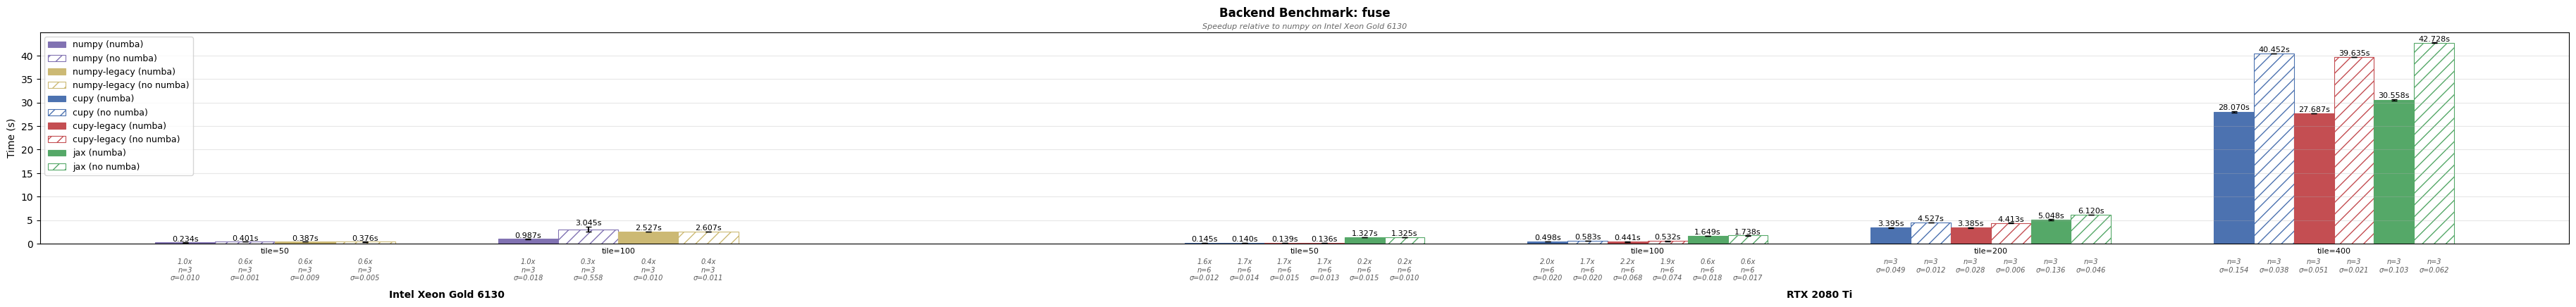

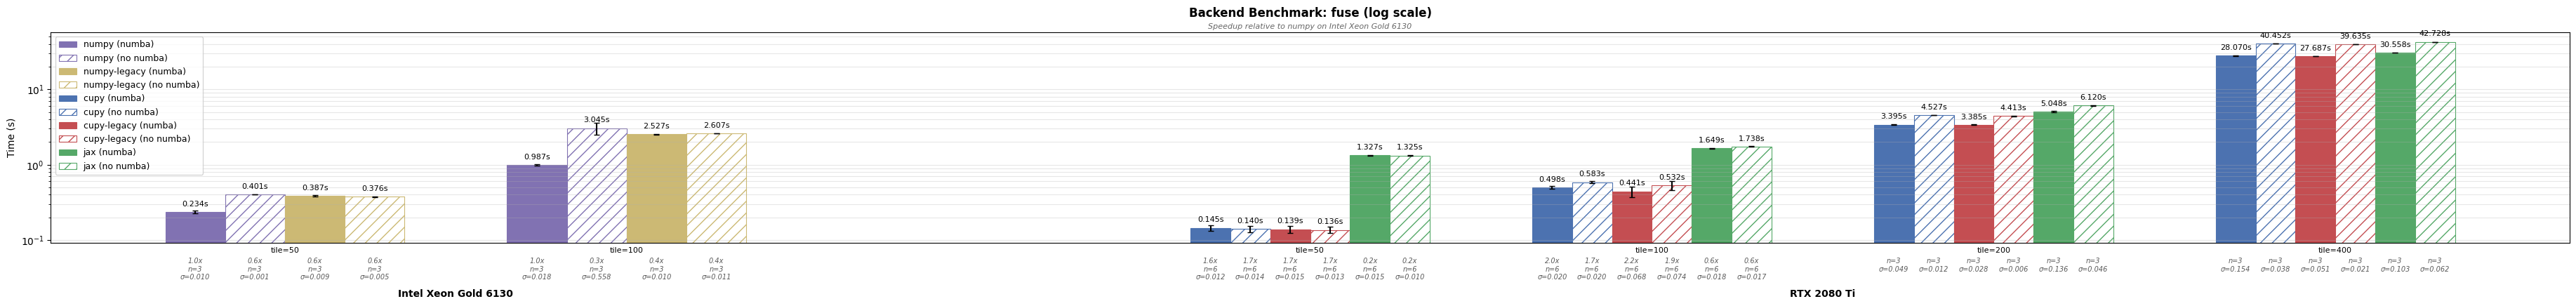

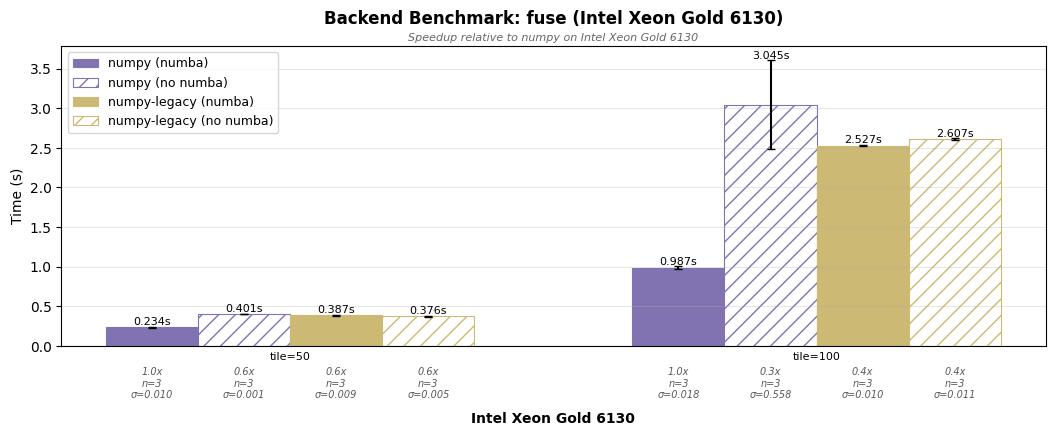

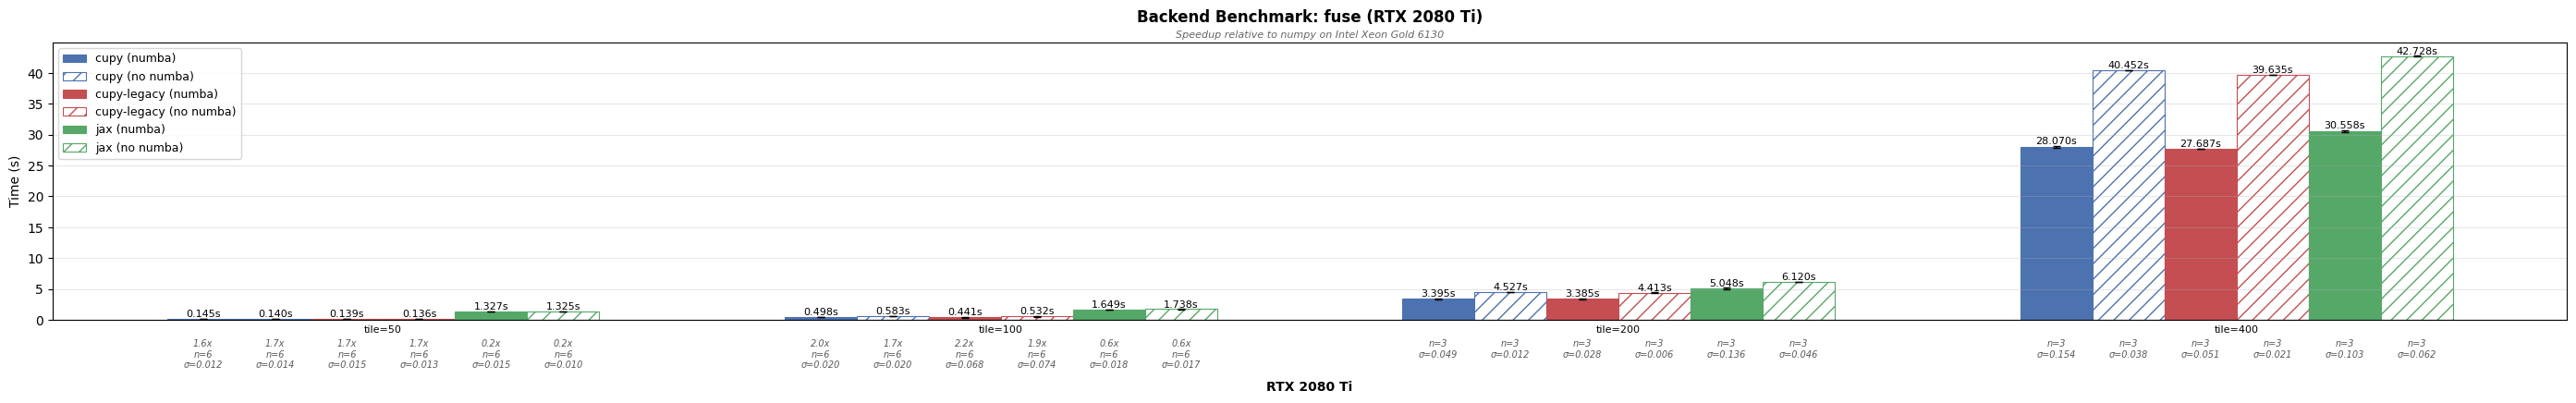

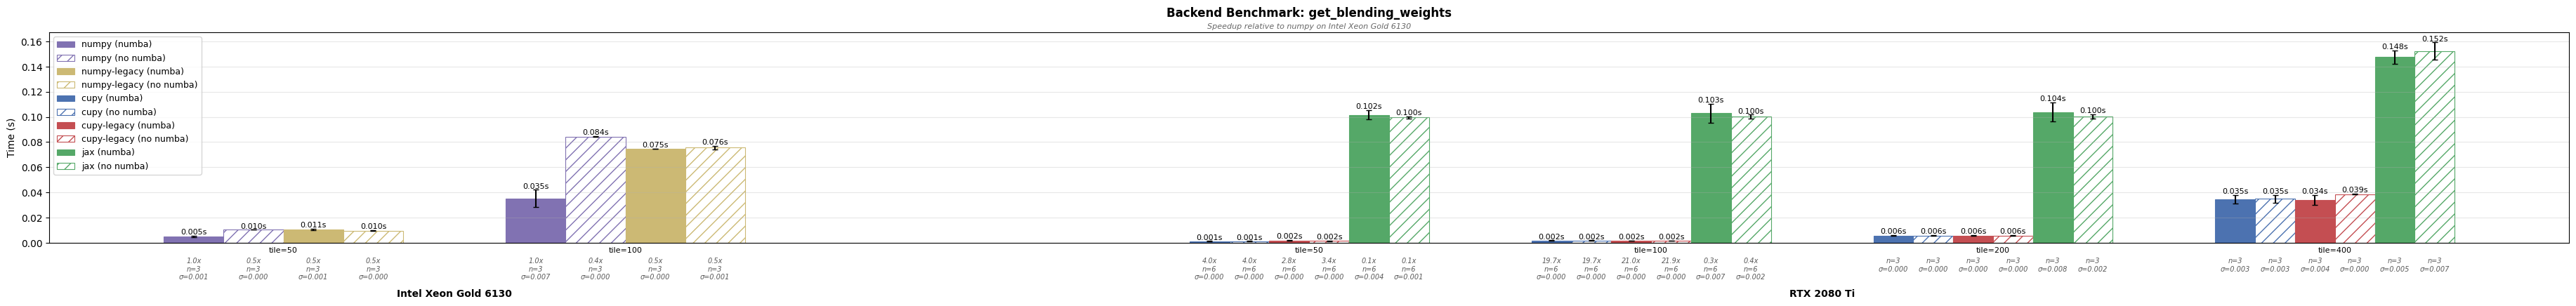

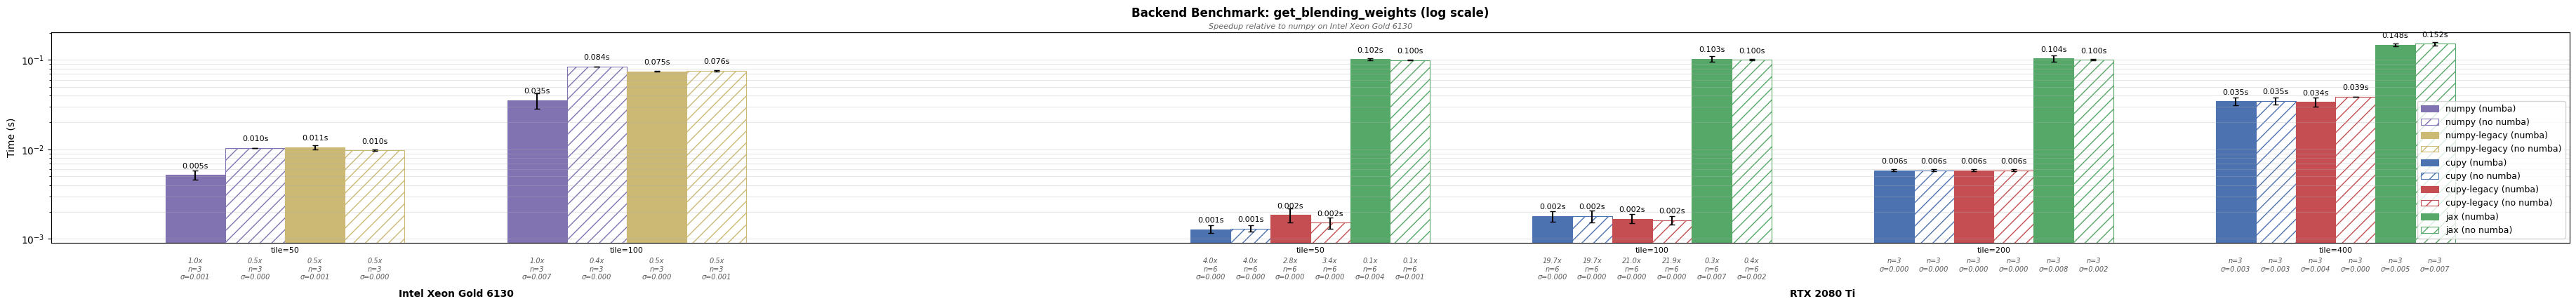

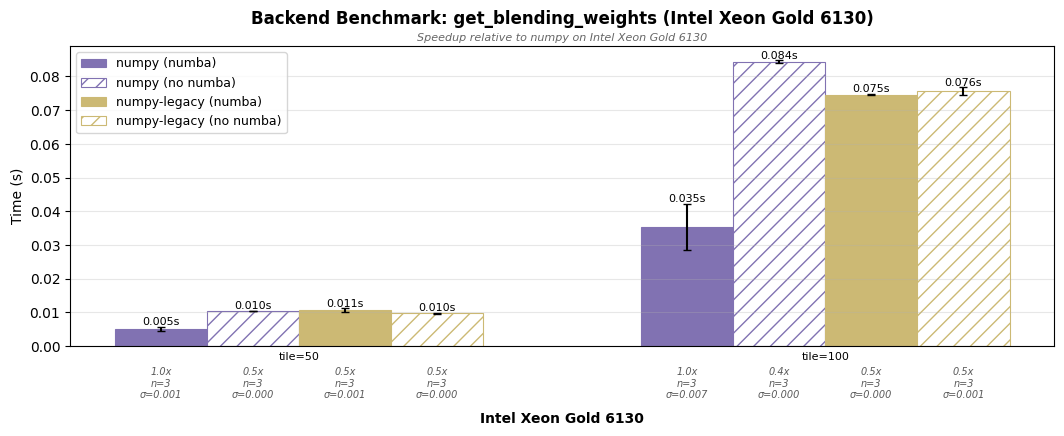

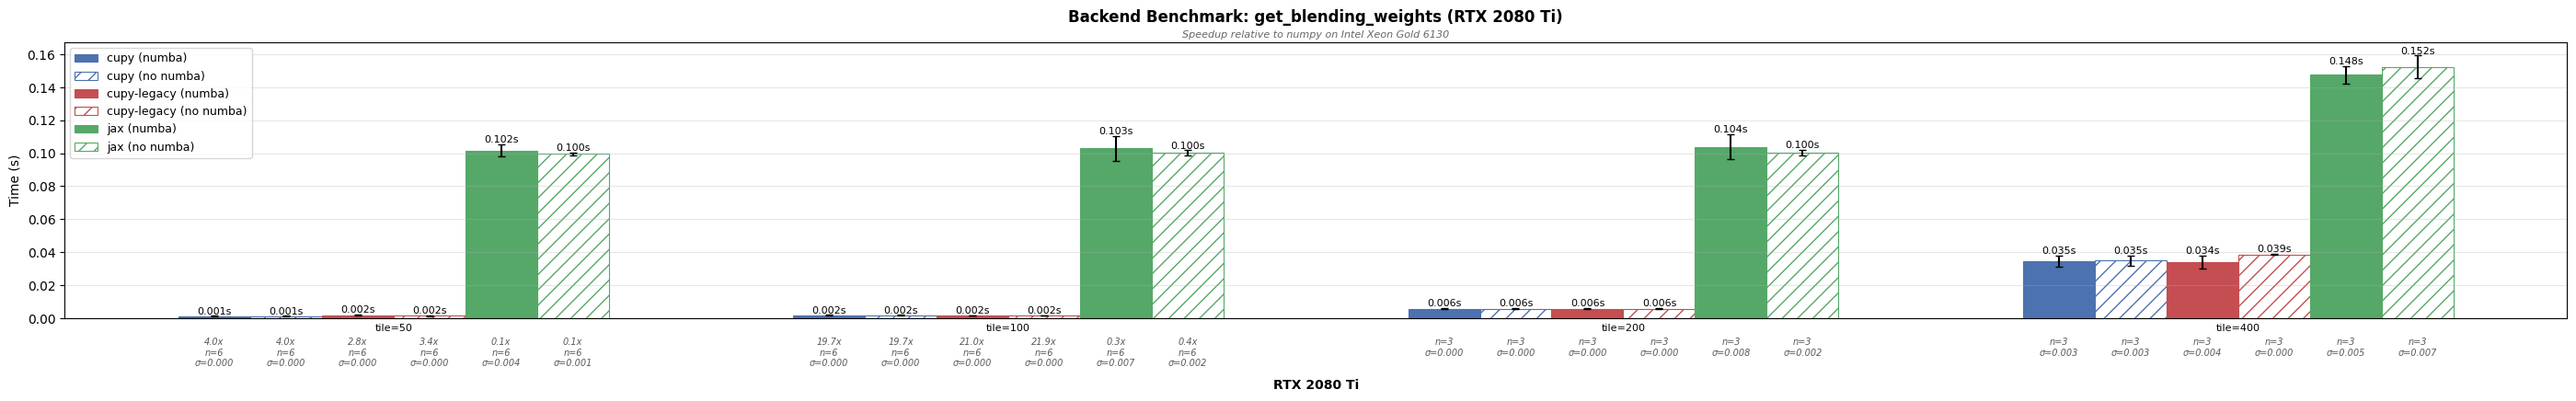

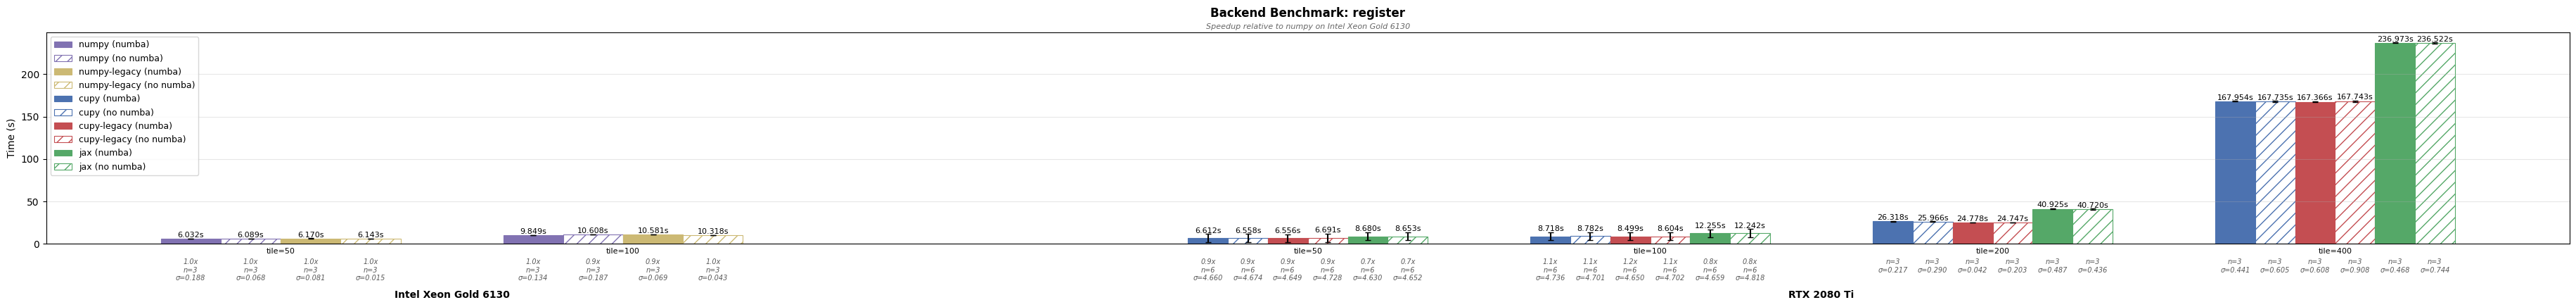

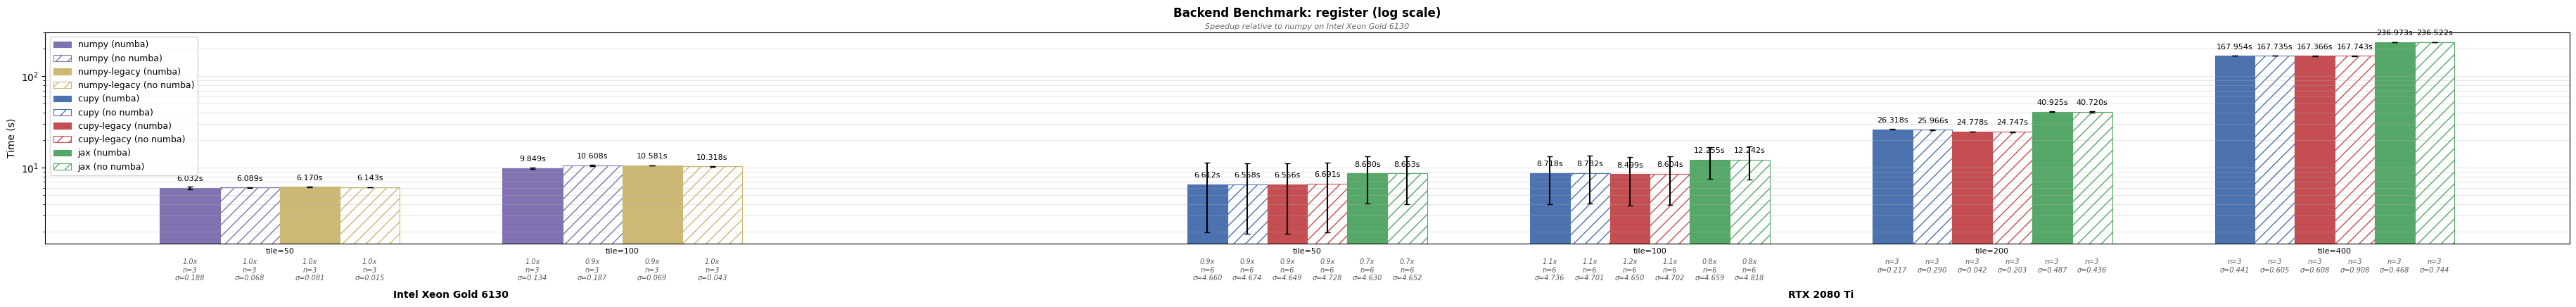

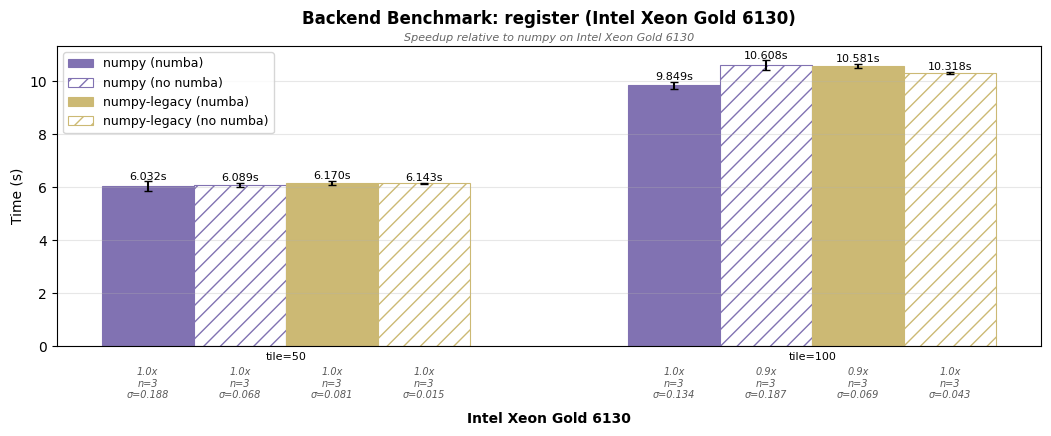

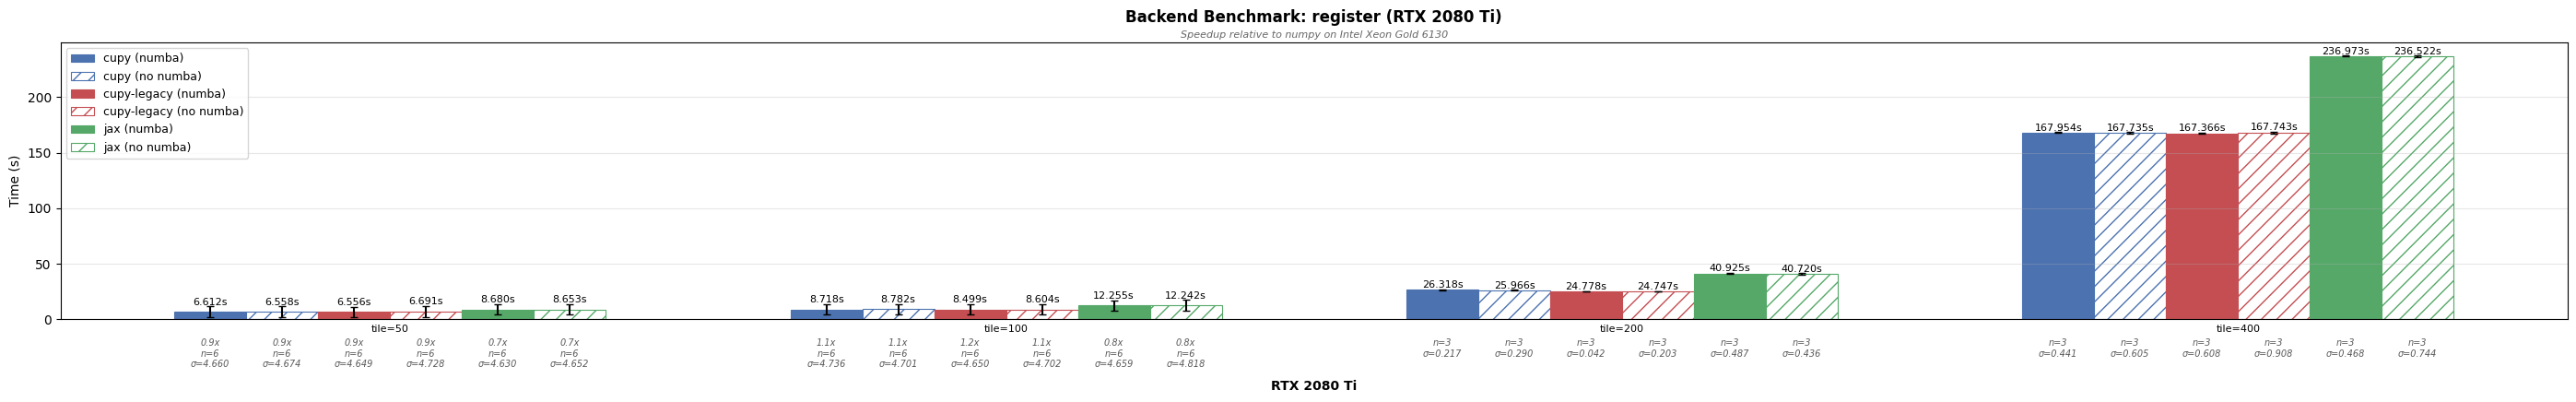

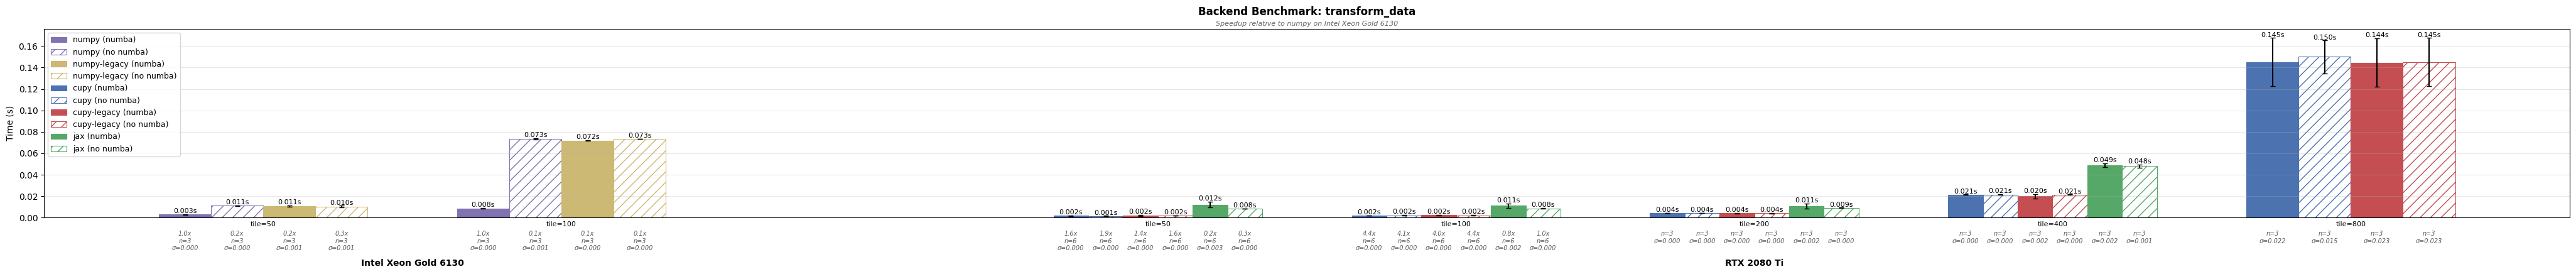

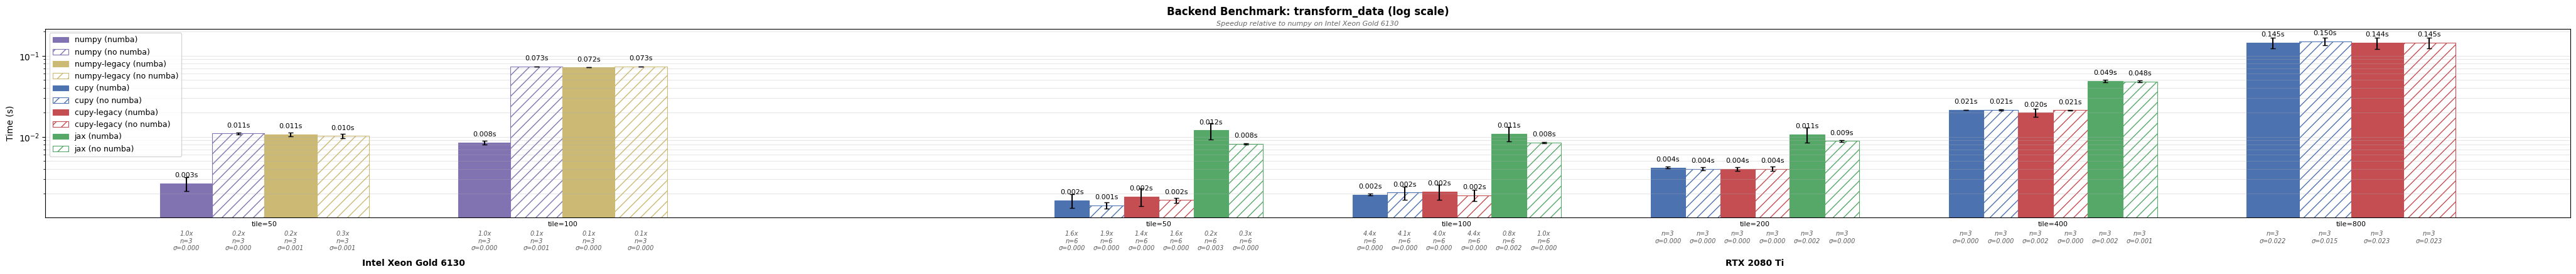

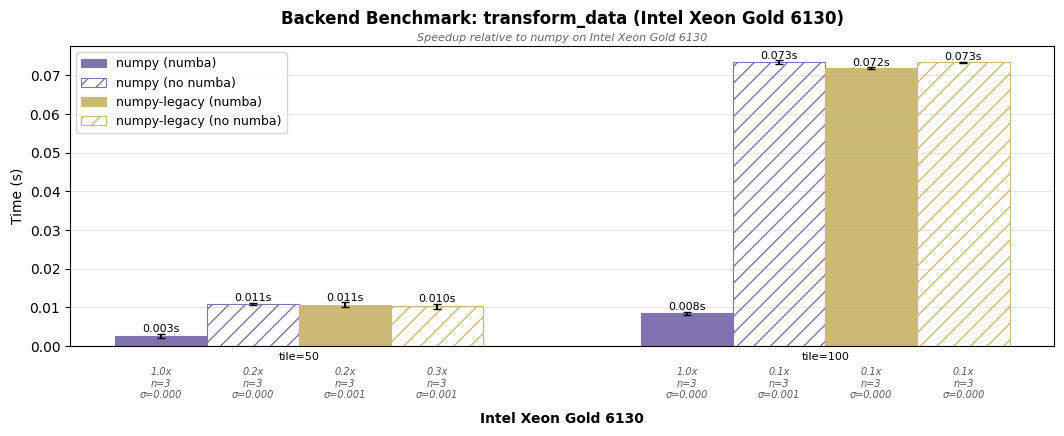

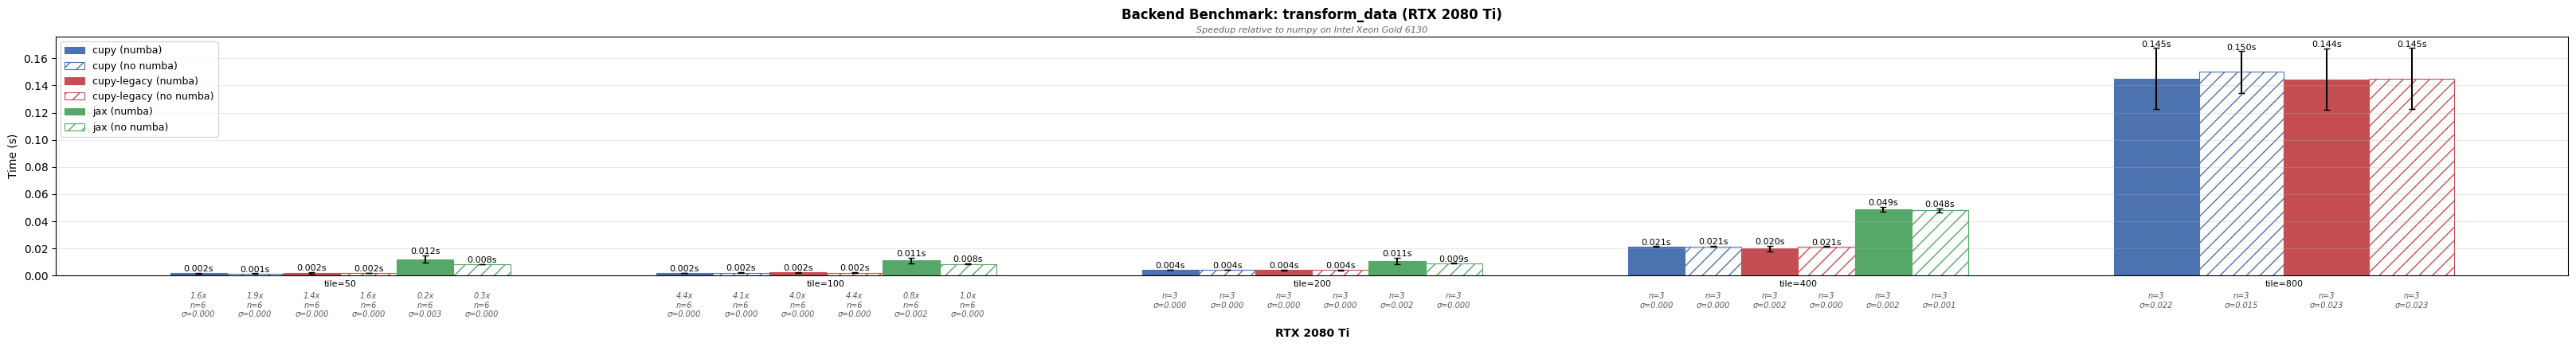

In [1]:
from multiview_stitcher.backends import evaluate_benchmarks, plot_runtime_and_speedup

merged = evaluate_benchmarks("benchmark_backends_results")
figures = plot_runtime_and_speedup(merged)

## 5. Tips and notes

**Dask scheduler.** CuPy fusion must use `scheduler="synchronous"` (or
the backend's `recommended_dask_scheduler`). The threaded scheduler causes
GPU memory contention and is actually slower.

**Global default.** Instead of passing `backend=` everywhere, set the
default once:
```python
multiview_stitcher.set_backend("cupy")
# All subsequent calls use CuPy unless overridden
```

**Registration speedup.** Registration operates on small, binned overlap
regions. The GPU speedup is modest unless `cucim` is installed for
GPU-native phase cross-correlation. Fusion benefits most because it
processes the full output volume.

**Custom fusion functions.** User-provided `fusion_func=` callables only
work with the NumPy backend. Built-in functions (`weighted_average_fusion`,
`max_fusion`) work with any backend.

**Memory.** For very large tiles, CuPy may run out of GPU memory. Reduce
`output_chunksize` in `fuse()` or fall back to NumPy for those chunks.